In [22]:
import pandas as pd
from operator import attrgetter
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
import numpy as np

Датасет
Файлы:

 olist_customers_dataset.csv — таблица с уникальными идентификаторами пользователей
customer_id — позаказный идентификатор пользователя

customer_unique_id — уникальный идентификатор пользователя (аналог номера паспорта)

customer_zip_code_prefix — почтовый индекс пользователя

customer_city — город доставки пользователя

customer_state — штат доставки пользователя

olist_orders_dataset.csv —  таблица заказов
order_id — уникальный идентификатор заказа (номер чека)

customer_id — позаказный идентификатор пользователя

order_status — статус заказа

order_purchase_timestamp — время создания заказа

order_approved_at — время подтверждения оплаты заказа

order_delivered_carrier_date — время передачи заказа в логистическую службу

order_delivered_customer_date — время доставки заказа

order_estimated_delivery_date — обещанная дата доставки

olist_order_items_dataset.csv — товарные позиции, входящие в заказы
order_id — уникальный идентификатор заказа (номер чека)

order_item_id — идентификатор товара внутри одного заказа

product_id — ид товара (аналог штрихкода)

seller_id — ид производителя товара

shipping_limit_date — максимальная дата доставки продавцом для передачи заказа партнеру по логистике

price — цена за единицу товара

freight_value — вес товара 

Пример структуры данных можно визуализировать по order_id == 00143d0f86d6fbd9f9b38ab440ac16f5

Уникальные статусы заказов в таблице olist_orders_dataset:

created — создан;
approved — подтверждён;
invoiced — выставлен счёт;
processing — в процессе сборки заказа;
shipped — отгружён со склада;
delivered — доставлен пользователю;
unavailable — заказ отменён по причине недоступности товара;;
canceled — отменён.

In [2]:
olist_customers_dataset = pd.read_csv('olist_customers_dataset.csv')
olist_order_items_dataset = pd.read_csv('olist_order_items_dataset.csv')
olist_orders_dataset = pd.read_csv('olist_orders_dataset.csv')

### Задача 1. Оценить месячный retention в оформление заказа с помощью когортного анализа.

In [3]:
olist_customers_dataset.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
# Отбираем уникальный покупателей
customer_unique = olist_customers_dataset[['customer_id', 'customer_unique_id']]

In [5]:
olist_orders_dataset.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
olist_orders_dataset = olist_orders_dataset.merge(
    customer_unique,
    on='customer_id',
    how='left'
)

In [7]:
olist_orders_dataset['order_purchase_timestamp'] = pd.to_datetime(olist_orders_dataset['order_purchase_timestamp'])

In [8]:
orders_dataset = olist_orders_dataset.query('order_status != "unavailable" and order_status != "canceled"')

In [9]:
orders_dataset.order_status.unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'created',
       'approved'], dtype=object)

In [10]:
# Извлекаем месяц и день заказа
orders_dataset['order_period'] = orders_dataset['order_purchase_timestamp'].dt.to_period('M')
orders_dataset['order_period_day'] = orders_dataset['order_purchase_timestamp'].dt.to_period('D')

/tmp/ipykernel_68/1379201836.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_dataset['order_period'] = orders_dataset['order_purchase_timestamp'].dt.to_period('M')
/tmp/ipykernel_68/1379201836.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_dataset['order_period_day'] = orders_dataset['order_purchase_timestamp'].dt.to_period('D')


In [11]:
orders_dataset.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,order_period,order_period_day
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,2017-10,2017-10-02
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,2018-07,2018-07-24
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11-18
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02-13


In [12]:
# Присваиваем когорты на основе даты первого действия для каждого пользователя
orders_dataset['cohort'] = orders_dataset.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')
orders_dataset['cohort_day'] = orders_dataset.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('D')

/tmp/ipykernel_68/55114646.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_dataset['cohort'] = orders_dataset.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')
/tmp/ipykernel_68/55114646.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_dataset['cohort_day'] = orders_dataset.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('D')


In [13]:
# Рассчитываем номер периода в днях (месячные периоды, деля на 30)
orders_dataset['period_number_month'] = np.floor((orders_dataset.order_period_day - orders_dataset.cohort_day).apply(attrgetter('n')) / 30)

/tmp/ipykernel_68/1968470789.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_dataset['period_number_month'] = np.floor((orders_dataset.order_period_day - orders_dataset.cohort_day).apply(attrgetter('n')) / 30)


In [14]:
# Агрегируем данные по когортам и рассчитанному номеру периода (в месяцах)
df_cohort = orders_dataset.groupby(['cohort', 'period_number_month']).agg(n_customers=('customer_unique_id', 'nunique')).reset_index()

In [15]:
df_cohort

,cohort,period_number_month,n_customers
0,2016-09,0.0,2
1,2016-10,0.0,290
2,2016-10,6.0,1
3,2016-10,9.0,1
4,2016-10,11.0,1
...,...,...,...
210,2018-06,1.0,22
211,2018-06,2.0,6
212,2018-07,0.0,6016
213,2018-07,1.0,6


In [16]:
# Создаем сводную таблицу для когортного анализа
cohort_pivot = df_cohort.pivot_table(index='cohort', columns='period_number_month', values='n_customers')

In [17]:
cohort_pivot

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,290.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,...,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,1.0,1.0
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,752.0,2.0,NaN,4.0,1.0,1.0,2.0,2.0,NaN,NaN,...,4.0,3.0,2.0,NaN,2.0,2.0,2.0,1.0,NaN,NaN
2017-02,1690.0,3.0,3.0,6.0,4.0,2.0,4.0,1.0,2.0,4.0,...,6.0,1.0,3.0,2.0,1.0,2.0,4.0,NaN,NaN,NaN
2017-03,2571.0,7.0,13.0,11.0,3.0,2.0,9.0,4.0,7.0,6.0,...,4.0,5.0,3.0,7.0,2.0,3.0,3.0,NaN,NaN,NaN
2017-04,2325.0,8.0,6.0,1.0,7.0,8.0,6.0,10.0,5.0,6.0,...,4.0,NaN,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN
2017-05,3541.0,15.0,15.0,12.0,13.0,12.0,12.0,4.0,10.0,9.0,...,11.0,7.0,4.0,8.0,5.0,NaN,NaN,NaN,NaN,NaN
2017-06,3102.0,12.0,14.0,11.0,4.0,16.0,9.0,6.0,4.0,11.0,...,8.0,2.0,8.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# Рассчитываем размеры когорт (первый столбец сводной таблицы)
cohort_size = cohort_pivot.iloc[:, 0]

In [19]:
# Вычисляем коэффициенты удержания, деля на размер когорты
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

In [20]:
retention_matrix

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003448,NaN,NaN,0.003448,...,0.003448,NaN,0.003448,NaN,0.003448,NaN,0.003448,0.006897,0.003448,0.003448
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.002660,NaN,0.005319,0.001330,0.001330,0.002660,0.002660,NaN,NaN,...,0.005319,0.003989,0.002660,NaN,0.002660,0.002660,0.002660,0.001330,NaN,NaN
2017-02,1.0,0.001775,0.001775,0.003550,0.002367,0.001183,0.002367,0.000592,0.001183,0.002367,...,0.003550,0.000592,0.001775,0.001183,0.000592,0.001183,0.002367,NaN,NaN,NaN
2017-03,1.0,0.002723,0.005056,0.004278,0.001167,0.000778,0.003501,0.001556,0.002723,0.002334,...,0.001556,0.001945,0.001167,0.002723,0.000778,0.001167,0.001167,NaN,NaN,NaN
2017-04,1.0,0.003441,0.002581,0.000430,0.003011,0.003441,0.002581,0.004301,0.002151,0.002581,...,0.001720,NaN,0.000860,0.000860,0.000860,0.000860,NaN,NaN,NaN,NaN
2017-05,1.0,0.004236,0.004236,0.003389,0.003671,0.003389,0.003389,0.001130,0.002824,0.002542,...,0.003106,0.001977,0.001130,0.002259,0.001412,NaN,NaN,NaN,NaN,NaN
2017-06,1.0,0.003868,0.004513,0.003546,0.001289,0.005158,0.002901,0.001934,0.001289,0.003546,...,0.002579,0.000645,0.002579,0.000967,NaN,NaN,NaN,NaN,NaN,NaN


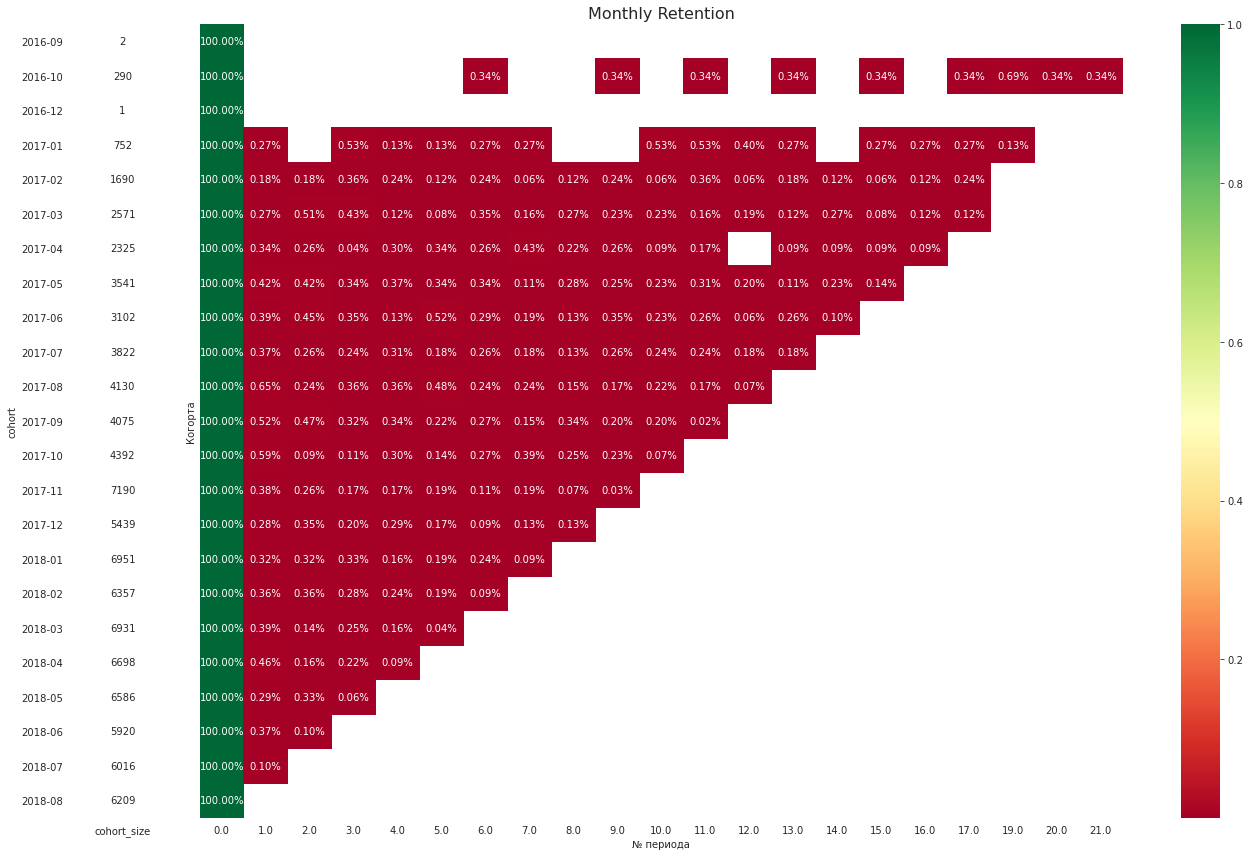

In [23]:
# Строим тепловую карту когортного анализа
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(19, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # Тепловая карта для коэффициентов удержания
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.2%',
                cmap='RdYlGn',
                ax=ax[1])
    ax[1].set_title('Monthly Retention', fontsize=16)
    ax[1].set(xlabel='№ периода', ylabel='Когорта')

    # Тепловая карта для размеров когорт
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.show()

In [24]:
# Проанализировать, чему равен медианный retention 1-го месяца
retention_month_1_median = retention_matrix.iloc[:, 1].median()

In [25]:
retention_month_1_median

0.003663003663003663

In [26]:
# Найти когорту с самым высоким retention на 3-й месяц.
retention_month_3_max = retention_matrix.iloc[:, 3].max()

In [27]:
#Сравниваем с таблицей и видим, что это когорта 2017-01
retention_month_3_max

0.005319148936170213

### Задача 2. Определить, существует ли product/market fit у маркетплейса.

Оценить наличие product/market fit у данного продукта с помощью когортного анализа, полученного на предыдущем шаге.
Пояснить свою позицию и сформулировать, на чём маркетплейс должен сконцентрироваться в ближайшее время. 
Если PMF есть, то в какую сторону лучше развивать продукт дальше? Если PMF нет, то какие причины могут быть у этого?
Подкрепить свои выводы релевантной визуализацией, удобной для восприятия.

#### Ответ

Product/market fit у маркетплейса отсутствует. Так как видно, что достаточно низкая возвращаемость после первой покупки. Также, чтобы утверждать, что PMF есть, показатель Retetion должен выравниться значительно выше 0. Поэтому масштабирование сейчас будет убыточным вариантом.

Причины отсутствия PMF:
1. Возможно продаются товары только длительного пользования(мебель, крупная техника), поэтому покупателям не требуется часто возвращаться.
2. Возможно на первый заказ есть большие скидки и второй и последующие заказы уже не так выгодно делать/дешевле у конкурента.
3. Неудобный интерфейс приложения. Поэтому после первого заказа, уходят к конкурентам.
4. Неудобный способ оплаты.
 
Сейчас маркетплейсу важно сконцентрироваться на возвращаемости пользователей:
1. Добавить больше многообразия среди товаров.
2. Продумать систему лояльности, чтобы было увеличить возвращаемость.
3. Проанализировать поведение покупателя в приложении и понять, есть ли в этом проблемы.
4. Проанализировать способы оплаты у конкурентов и при необходимости добавить новый.


In [28]:
### Одна из причин могла быть не соблюдение сроков доставки. Поэтому я проверила эту теорию.
olist_orders_dataset.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6


In [29]:
olist_orders_dataset['order_delivered_customer_date'] = pd.to_datetime(olist_orders_dataset['order_delivered_customer_date'])
olist_orders_dataset['order_estimated_delivery_date'] = pd.to_datetime(olist_orders_dataset['order_estimated_delivery_date'])

In [30]:
olist_orders_dataset['order_delta_delivery_date'] = (olist_orders_dataset.order_estimated_delivery_date - olist_orders_dataset.order_delivered_customer_date).dt.days

In [31]:
### Процент заказов недоставленных вовремя.
rate_order_not_time = olist_orders_dataset.query('order_delta_delivery_date < 0').order_delta_delivery_date.count() / olist_orders_dataset.order_delta_delivery_date.count() * 100

In [32]:
### 8% от общей доли заказов, поэтому не является причиной отсутствия PMF
rate_order_not_time

8.112898544715783

In [33]:
### Процент отмененных заказов.
canceled_order = olist_orders_dataset.query('order_status == "canceled"').order_status.count() / olist_orders_dataset.order_status.count() * 100

In [34]:
canceled_order

0.6285133898492574

In [35]:
### Процент отмененных заказов из-за недоступности товара.
unavailable_order = olist_orders_dataset.query('order_status == "unavailable"').order_status.count() / olist_orders_dataset.order_status.count() * 100

In [36]:
unavailable_order

0.6124234470691163

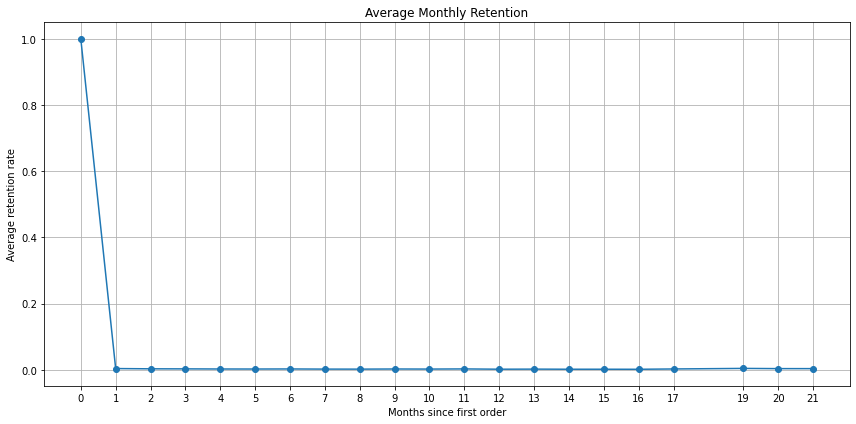

In [37]:
mean_retention = retention_matrix.mean()

plt.figure(figsize=(12, 6))

plt.plot(
    mean_retention.index,
    mean_retention.values,
    marker='o'
)

plt.title('Average Monthly Retention')
plt.xlabel('Months since first order')
plt.ylabel('Average retention rate')
plt.xticks(mean_retention.index)
plt.grid(True)
plt.tight_layout()
plt.show()

### Задача 3. Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

Вы разобрались с наличием product/market fit. Теперь вас просят сформулировать продуктовые метрики маркетплейса, чтобы компания могла на них ориентироваться.

### Первая метрика должна отражать рост объёма продаж маркетплейса.

Я решила взять две метрики:
1. Месячный объем продаж.
2. Средняя выручка на пользователя.

1. Месячный объем продаж

In [38]:
olist_order_items_dataset['sum_orders'] = olist_order_items_dataset.order_item_id * olist_order_items_dataset.price

In [39]:
orders_df = olist_orders_dataset.query("order_status == 'delivered'")[['order_id', 'customer_unique_id', 'order_delivered_customer_date']].merge(
    olist_order_items_dataset[['order_id', 'sum_orders']],
    on='order_id',
    how='left'
)

In [40]:
orders_df.head()

,order_id,customer_unique_id,order_delivered_customer_date,sum_orders
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-10 21:25:13,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-08-07 15:27:45,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-17 18:06:29,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-12-02 00:28:42,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-16 18:17:02,19.90


In [41]:
orders_df['order_delivered_customer_date'] = orders_df['order_delivered_customer_date'].dt.to_period('M')

In [42]:
df = orders_df.groupby(['order_delivered_customer_date'], as_index=False).agg(all_orders = ('sum_orders', 'sum'))

In [43]:
df['order_delivered_customer_date'] = df['order_delivered_customer_date'].dt.to_timestamp()

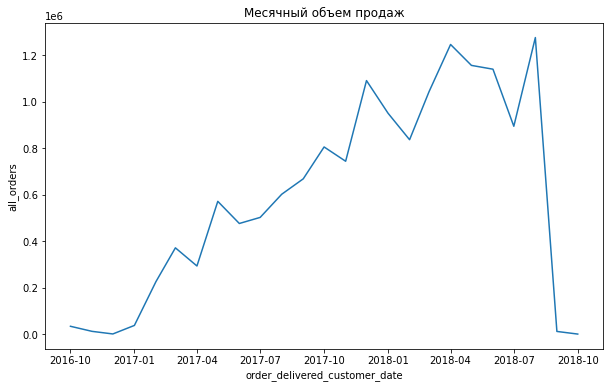

In [44]:
plt.figure(figsize=(10, 6))
plt.title("Месячный объем продаж") 
sns.lineplot(data=df, x="order_delivered_customer_date", y="all_orders")


2. Средняя выручка на пользователя

In [45]:
apru_df = orders_df.groupby('order_delivered_customer_date', as_index=False).agg(total=('sum_orders', 'sum'), customers=('customer_unique_id', 'count'))

In [46]:
apru_df

,order_delivered_customer_date,total,customers
0,2016-10,33742.38,241
1,2016-11,11989.05,72
2,2016-12,758.86,4
3,2017-01,37449.27,326
4,2017-02,225747.52,1565
5,2017-03,371055.94,2724
6,2017-04,293043.97,2072
7,2017-05,570994.15,4201
8,2017-06,475815.28,3640
9,2017-07,501973.75,3933


In [47]:
apru_df['apru'] = apru_df.total /  apru_df.customers

In [48]:
apru_df['order_delivered_customer_date'] = apru_df['order_delivered_customer_date'].dt.to_timestamp()

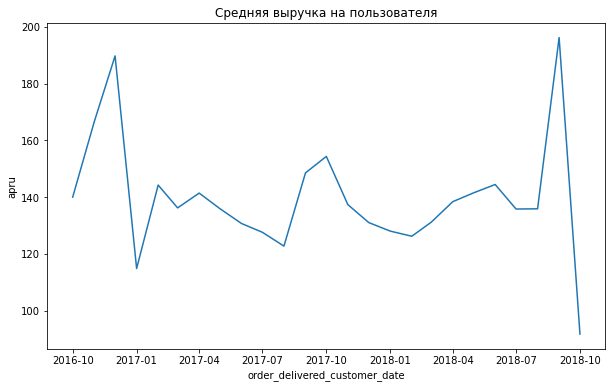

In [49]:
plt.figure(figsize=(10, 6))
plt.title("Средняя выручка на пользователя") 
sns.lineplot(data=apru_df, x="order_delivered_customer_date", y="apru")

### Вторая — показывать объем аудитории, которой продукт доставляет ценность.

Ценность нашего продукта - это получение товара нашим покупателем.
Метрика MAU по доставленным товарам

In [50]:
orders_dataset.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,order_period,order_period_day,cohort,cohort_day,period_number_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,2017-10,2017-10-02,2017-09,2017-09-04,0.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,2018-07,2018-07-24,2018-07,2018-07-24,0.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08-08,2018-08,2018-08-08,0.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11-18,2017-11,2017-11-18,0.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02-13,2018-02,2018-02-13,0.0


In [51]:
orders_dataset['order_delivered_customer_date'] = pd.to_datetime(orders_dataset['order_delivered_customer_date'])

/tmp/ipykernel_68/2071007978.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_dataset['order_delivered_customer_date'] = pd.to_datetime(orders_dataset['order_delivered_customer_date'])


In [52]:
orders_dataset['order_delivered_period'] = orders_dataset['order_delivered_customer_date'].dt.to_period('M')

/tmp/ipykernel_68/2933802307.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_dataset['order_delivered_period'] = orders_dataset['order_delivered_customer_date'].dt.to_period('M')


In [53]:
MAU_delivered = orders_dataset[orders_dataset['order_status'] == 'delivered'].groupby('order_delivered_period', as_index=False).agg(active_customers=('customer_unique_id','nunique'))

In [54]:
MAU_delivered

,order_delivered_period,active_customers
0,2016-10,203
1,2016-11,58
2,2016-12,4
3,2017-01,264
4,2017-02,1328
5,2017-03,2354
6,2017-04,1821
7,2017-05,3699
8,2017-06,3171
9,2017-07,3403


In [55]:
MAU_delivered['order_delivered_period'] = MAU_delivered['order_delivered_period'].dt.to_timestamp()

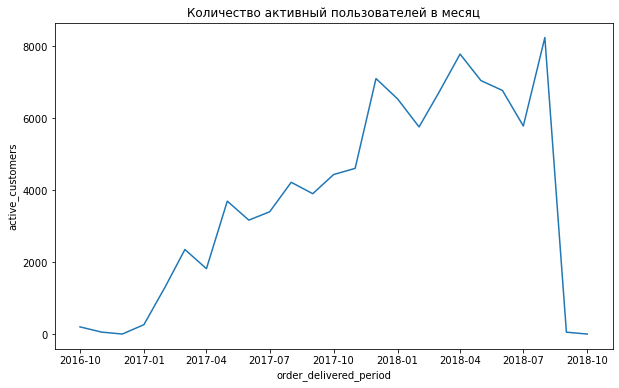

In [56]:
plt.figure(figsize=(10, 6))
plt.title("Количество активный пользователей в месяц") 
sns.lineplot(data=MAU_delivered, x="order_delivered_period", y="active_customers")

### Третья — отражать заинтересованность новых клиентов в продукте (даже если вы не можете посчитать ее на имеющихся у вас данных).

- Средняя длина сессии. 
Интересно ли просматривать товары, выбирать.
- Конверсия в повторное использование приложения.
Возвращается ли после первого касания.

### Четвёртая — отражать вовлеченность клиента в продолжение использования продукта.

Retention rate

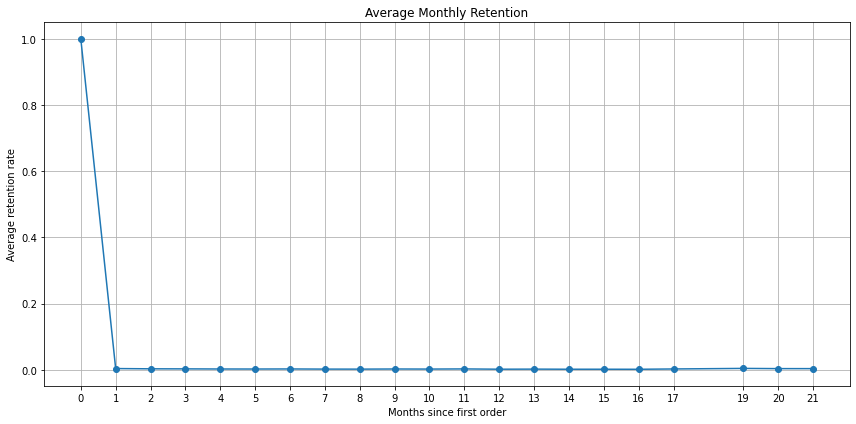

In [57]:
plt.figure(figsize=(12, 6))

plt.plot(
    mean_retention.index,
    mean_retention.values,
    marker='o'
)

plt.title('Average Monthly Retention')
plt.xlabel('Months since first order')
plt.ylabel('Average retention rate')
plt.xticks(mean_retention.index)
plt.grid(True)
plt.tight_layout()
plt.show()

Или Churn Rate
Посмотреть долю пользователей, которые перестали пользоваться приложением

In [58]:
churn_matrix = 1 - retention_matrix

In [59]:
churn_matrix

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,0.0,NaN,NaN,NaN,NaN,NaN,0.996552,NaN,NaN,0.996552,...,0.996552,NaN,0.996552,NaN,0.996552,NaN,0.996552,0.993103,0.996552,0.996552
2016-12,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,0.0,0.997340,NaN,0.994681,0.998670,0.998670,0.997340,0.997340,NaN,NaN,...,0.994681,0.996011,0.997340,NaN,0.997340,0.997340,0.997340,0.998670,NaN,NaN
2017-02,0.0,0.998225,0.998225,0.996450,0.997633,0.998817,0.997633,0.999408,0.998817,0.997633,...,0.996450,0.999408,0.998225,0.998817,0.999408,0.998817,0.997633,NaN,NaN,NaN
2017-03,0.0,0.997277,0.994944,0.995722,0.998833,0.999222,0.996499,0.998444,0.997277,0.997666,...,0.998444,0.998055,0.998833,0.997277,0.999222,0.998833,0.998833,NaN,NaN,NaN
2017-04,0.0,0.996559,0.997419,0.999570,0.996989,0.996559,0.997419,0.995699,0.997849,0.997419,...,0.998280,NaN,0.999140,0.999140,0.999140,0.999140,NaN,NaN,NaN,NaN
2017-05,0.0,0.995764,0.995764,0.996611,0.996329,0.996611,0.996611,0.998870,0.997176,0.997458,...,0.996894,0.998023,0.998870,0.997741,0.998588,NaN,NaN,NaN,NaN,NaN
2017-06,0.0,0.996132,0.995487,0.996454,0.998711,0.994842,0.997099,0.998066,0.998711,0.996454,...,0.997421,0.999355,0.997421,0.999033,NaN,NaN,NaN,NaN,NaN,NaN


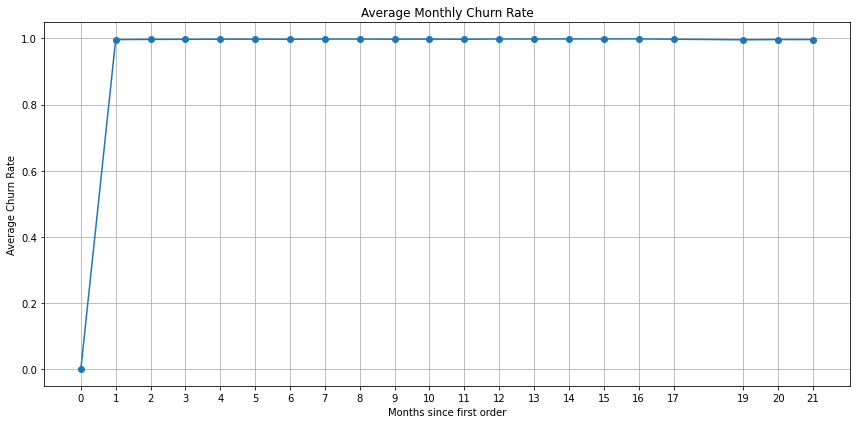

In [60]:
mean_churn = churn_matrix.mean()
plt.figure(figsize=(12, 6))

plt.plot(
    mean_churn.index,
    mean_churn.values,
    marker='o'
)

plt.title('Average Monthly Churn Rate')
plt.xlabel('Months since first order')
plt.ylabel('Average Churn Rate')
plt.xticks(mean_churn.index)
plt.grid(True)
plt.tight_layout()
plt.show()

### Пятая — отражать денежное выражение вовлеченности клиента.

Метрика LTV

In [61]:
olist_order_items_dataset['total_sum'] = olist_order_items_dataset.price * olist_order_items_dataset.order_item_id

In [62]:
olist_order_items_dataset.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,sum_orders,total_sum
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,58.90,58.90
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,239.90,239.90
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,199.00,199.00
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,12.99,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,199.90,199.90


In [63]:
olist_orders_dataset.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,order_delta_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,7.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,5.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,17.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,12.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9.0


In [64]:
LTV_df = olist_orders_dataset[['customer_unique_id', 'order_id', 'order_purchase_timestamp']].merge(
    olist_order_items_dataset[['order_id', 'total_sum']],
    on='order_id',
    how='left'
)

In [65]:
LTV_df['order_period'] = LTV_df['order_purchase_timestamp'].dt.to_period('M')
LTV_df['order_period_day'] = LTV_df['order_purchase_timestamp'].dt.to_period('D')

In [66]:
# Присваиваем когорты на основе даты первого действия для каждого пользователя
LTV_df['cohort'] = LTV_df.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')
LTV_df['cohort_day'] = LTV_df.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('D')

In [67]:
# Рассчитываем номер периода в днях (месячные периоды, деля на 30)
LTV_df['period_number_month'] = np.floor((LTV_df.order_period_day - LTV_df.cohort_day).apply(attrgetter('n')) / 30)

In [68]:
# Агрегируем данные по когортам и рассчитанному номеру периода (в месяцах)
data_cohort = LTV_df.groupby(['cohort', 'period_number_month']).agg(n_customers=('customer_unique_id', 'nunique'), total = ('total_sum', 'sum')).reset_index()

In [69]:
data_cohort

,cohort,period_number_month,n_customers,total
0,2016-09,0.0,4,435.23
1,2016-10,0.0,321,56103.79
2,2016-10,6.0,1,99.99
3,2016-10,9.0,1,339.00
4,2016-10,11.0,1,49.00
...,...,...,...,...
215,2018-07,2.0,1,0.00
216,2018-08,0.0,6271,927299.29
217,2018-08,1.0,4,0.00
218,2018-09,0.0,5,0.00


In [70]:
data_cohort['LTV_cohort'] = data_cohort.n_customers / data_cohort.total

In [71]:
cohort_pivot = data_cohort.pivot_table(index='cohort', columns='period_number_month', values='total')

In [72]:
cohort_pivot

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,435.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,56103.79,NaN,NaN,NaN,NaN,NaN,99.99,NaN,NaN,339.00,...,49.00,NaN,230.40,NaN,298.6,NaN,98.00,289.28,132.4,25.99
2016-12,21.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,142191.32,82.89,NaN,274.70,59.99,96.00,479.41,145.60,NaN,NaN,...,541.05,333.89,126.90,NaN,194.9,93.90,284.79,38.00,NaN,NaN
2017-02,270096.64,203.08,344.80,701.08,419.36,769.70,198.98,319.90,432.80,882.22,...,521.78,130.99,279.80,143.80,117.0,407.60,534.80,NaN,NaN,NaN
2017-03,412513.91,873.59,2842.32,967.30,498.89,958.00,1023.46,775.70,1333.49,262.57,...,667.23,562.30,288.69,718.80,587.6,264.89,293.59,NaN,NaN,NaN
2017-04,399778.03,1005.24,969.17,59.90,1816.46,1519.20,1959.62,2615.67,418.80,571.38,...,828.00,NaN,324.90,440.65,794.9,343.99,NaN,NaN,NaN,NaN
2017-05,558579.11,1459.13,4216.23,1410.42,1537.88,2378.00,1418.17,309.75,2591.58,1613.04,...,1557.06,550.48,129.78,1111.68,493.1,NaN,NaN,NaN,NaN,NaN
2017-06,466542.75,3794.69,3372.90,908.79,1889.48,2250.00,1128.83,613.57,247.87,1765.18,...,2094.48,149.73,1608.08,1386.90,NaN,NaN,NaN,NaN,NaN,NaN


In [73]:
cohort_size = cohort_pivot.iloc[:, 0]

In [74]:
LTV_retetion_matrix = cohort_pivot.divide(cohort_size, axis=0)

In [75]:
LTV_retetion_matrix

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.001782,NaN,NaN,0.006042,...,0.000873,NaN,0.004107,NaN,0.005322,NaN,0.001747,0.005156,0.00236,0.000463
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.000583,NaN,0.001932,0.000422,0.000675,0.003372,0.001024,NaN,NaN,...,0.003805,0.002348,0.000892,NaN,0.001371,0.000660,0.002003,0.000267,NaN,NaN
2017-02,1.0,0.000752,0.001277,0.002596,0.001553,0.002850,0.000737,0.001184,0.001602,0.003266,...,0.001932,0.000485,0.001036,0.000532,0.000433,0.001509,0.001980,NaN,NaN,NaN
2017-03,1.0,0.002118,0.006890,0.002345,0.001209,0.002322,0.002481,0.001880,0.003233,0.000637,...,0.001617,0.001363,0.000700,0.001742,0.001424,0.000642,0.000712,NaN,NaN,NaN
2017-04,1.0,0.002514,0.002424,0.000150,0.004544,0.003800,0.004902,0.006543,0.001048,0.001429,...,0.002071,NaN,0.000813,0.001102,0.001988,0.000860,NaN,NaN,NaN,NaN
2017-05,1.0,0.002612,0.007548,0.002525,0.002753,0.004257,0.002539,0.000555,0.004640,0.002888,...,0.002788,0.000986,0.000232,0.001990,0.000883,NaN,NaN,NaN,NaN,NaN
2017-06,1.0,0.008134,0.007230,0.001948,0.004050,0.004823,0.002420,0.001315,0.000531,0.003784,...,0.004489,0.000321,0.003447,0.002973,NaN,NaN,NaN,NaN,NaN,NaN


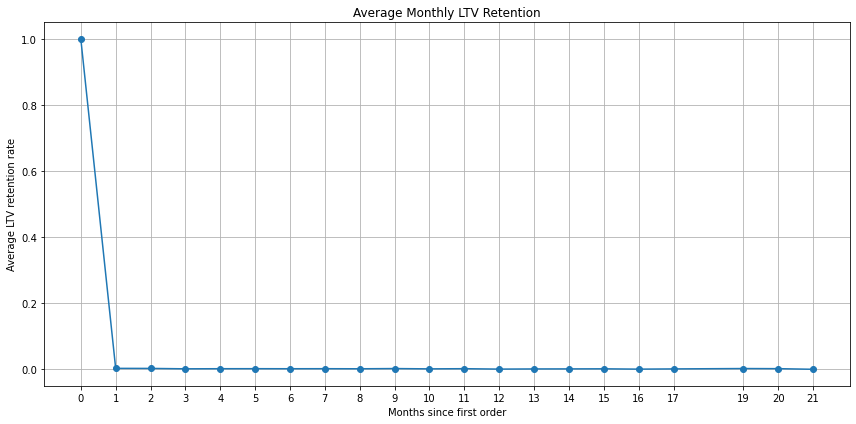

In [76]:
mean_LTV_retention = LTV_retetion_matrix.mean()

plt.figure(figsize=(12, 6))

plt.plot(
    mean_LTV_retention.index,
    mean_LTV_retention.values,
    marker='o'
)

plt.title('Average Monthly LTV Retention')
plt.xlabel('Months since first order')
plt.ylabel('Average LTV retention rate')
plt.xticks(mean_LTV_retention.index)
plt.grid(True)
plt.tight_layout()
plt.show()

### Задача 4. Выбрать одну из 3 основных гипотез с помощью фреймворка ICE.

Посмотрев с продактом на когортный анализ и метрики, вы решили, что нужно изменить продукт. Метрики необходимо срочно повышать. Вместе с командой вы сформулировали 3 гипотезы, в которые вы верите. По каждой гипотезе команда заполнила показатели по Ease, Confidence. Вам нужно заполнить самый важный показатель — Impact. Для этого вам требуется:

Выбрать одну из трёх основных гипотез с помощью фреймворка ICE, которые были сформированы продактом и, кажется, должны улучшить пользовательский опыт в маркетплейсе.

Для расчёта Impact возьмите данные с июня 2017 года. Считайте, что конверсия в повторный заказ равна величине медианного retention 1-го месяца (см. пункт 1 проекта).

#### Гипотеза 1

Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.


In [77]:
olist_orders_dataset.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date             object
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                       object
order_delta_delivery_date               float64
dtype: object

In [78]:
olist_orders_dataset.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,order_delta_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,7.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,5.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,17.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,12.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9.0


In [79]:
### Impact
olist_orders_dataset.query('order_status == "canceled" and order_purchase_timestamp > "2017-05-31"').order_id.nunique()

502

In [80]:
### 504 по шкале равно 4
### Тогда ICE первой гипотезы = 192

ICE_one = 4 * 8 * 6
ICE_one

192

#### Гипотеза 2

Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов. 

In [81]:
### на задании 2 я уже смотрела количество заказов, недоставленных вовремя. 
### Уже есть колонка с разницей от времени доставки к обещанному времени доставки - order_delta_delivery_date
Impact_two = olist_orders_dataset.query('order_purchase_timestamp > "2017-05-31" and order_delta_delivery_date < 0').order_id.nunique() * retention_month_1_median

In [82]:
Impact_two

26.736263736263737

In [83]:
### 26.7 по шкале равно 1
### Тогда ICE второй гипотезы = 

ICE_two = 1 * 10 * 4
ICE_two

40

#### Гипотеза 3

Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ.

In [84]:
Impact_three = olist_orders_dataset.query('order_purchase_timestamp > "2017-05-31"').groupby('customer_unique_id', as_index=False).agg(orders = ('order_id', 'nunique')).customer_unique_id.nunique()

In [85]:
Impact_three * retention_month_1_median

311.8827838827839

In [86]:
### 311.9 по шкале равно 3
### Тогда ICE второй гипотезы = 

ICE_three = 3 * 5 * 9
ICE_three

135

##### Ответ:
У гипотезы 1 наибольшее значение по IСE.
Поэтому в первую очередь нужно протестировать ее.


### Задача 5. Сформулировать нужные метрики, на которые ваша гипотеза должна повлиять.

После предыдущего исследования у вас появилась гипотеза, которую можно реализовать для значительного улучшения метрик компании. Вы предложили использовать A/B-тестирование для проверки её эффективности.

Продакт попросил вас:

Сформулировать метрики, на которые должна повлиять выбранная вами гипотеза.
Сформулировать хотя бы по одной метрике в категории: целевые, прокси, guardrail и объяснить свой выбор.

#### Гипотеза
Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

#### Метрики

##### Целевые
1. Количество доставленных заказов. - Это основная цель гипотезы: стало ли больше доставленных заказов.
2. Общая выручка. - Увелечение доставленных товаров в денежном эквиваленте.

##### Proxy
1. Конверсия в доставленные заказы. - достоверна, интерпретируема и нечувствительна. 
2. Коверсия заказов со статусами: processing и shipped. - Если по воронке этих статусов будет становиться больше, то значит меньше отваливается покупателей.

##### Guardrail
1. Обращение в поддержку - Убеждаемся, что исправление бага, не сломало что-то еще в другом месте. 
2. Конверсия отменных заказов из-за их недоступности. - Важно, чтобы товары были в наличии и мы покупатель почувствовал нашу ценность.



## Отчет

 Из-за того, что выручка маркетплейса стоит на месте уже несколько месяцев был проведен анализ данных.
 
 Я смотрела на:
 - возвращаемость пользователей
 - есть ли product/market fit у нашего приложения
 
 Из данных я выявила, что в основном наши пользователи делают только первый заказ и не возвращаются для последующих заказов. 
 На графике видно, что кривая Retention не выходит на плато. А это значит, что мы тратим деньги на привлечение новых клиентов, но они делают только одну покупку. Из-за этого мы не накапливаем постоянных активных пользователей.

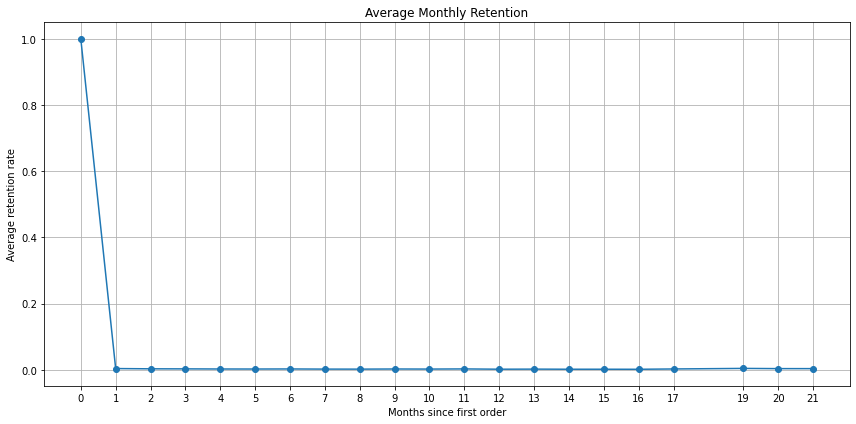

In [87]:
mean_retention = retention_matrix.mean()

plt.figure(figsize=(12, 6))

plt.plot(
    mean_retention.index,
    mean_retention.values,
    marker='o'
)

plt.title('Average Monthly Retention')
plt.xlabel('Months since first order')
plt.ylabel('Average retention rate')
plt.xticks(mean_retention.index)
plt.grid(True)
plt.tight_layout()
plt.show()

На графике LTV retetion видно, что в денежном выражении, что покупатели совершают только одну покупку.

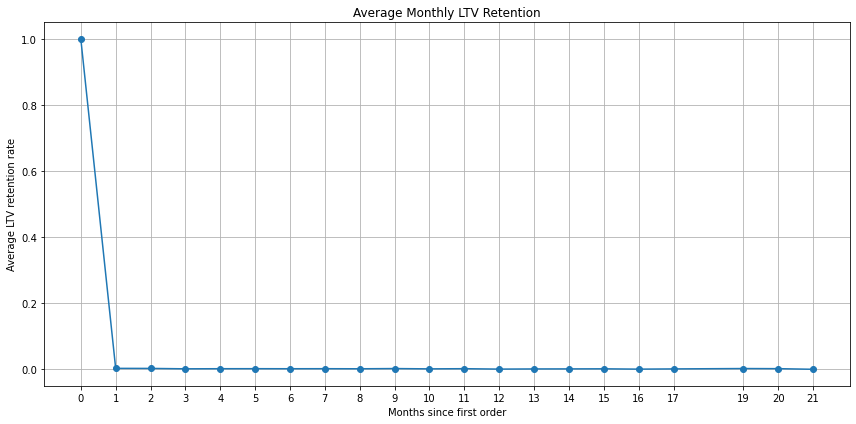

In [88]:
plt.figure(figsize=(12, 6))

plt.plot(
    mean_LTV_retention.index,
    mean_LTV_retention.values,
    marker='o'
)

plt.title('Average Monthly LTV Retention')
plt.xlabel('Months since first order')
plt.ylabel('Average LTV retention rate')
plt.xticks(mean_LTV_retention.index)
plt.grid(True)
plt.tight_layout()
plt.show()

Мы наблюдаем резкое падение активных пользователей (MAU) и продаж. Это требует дополнительного исследования: так как это возможно ошибка в данных или их сборе или критичный баг.

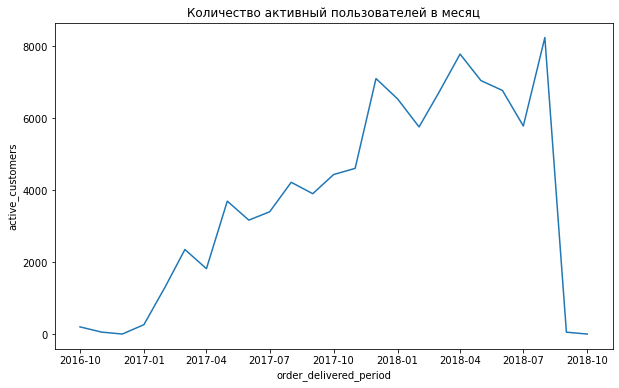

In [89]:
plt.figure(figsize=(10, 6))
plt.title("Количество активный пользователей в месяц") 
sns.lineplot(data=MAU_delivered, x="order_delivered_period", y="active_customers")

#### Выводы

1. На основе скоринга ICE рекомендую исправить баг в системе процессинга заказов. Это гипотеза с самым высоким приоритетом (Score: 192), которая позволит сразу снизить процент отмен и увеличить количество доставленных заказов без затрат на маркетинг. 
2. Необходимо сконцентрироваться на добавлении товаров, в которых более часто нуждаются покупатели.
3. Необходимо внедрить пуш-уведомления, систему лояльности и тп, чтобы подтолкнуть ко второй и последующих покупок.
4. Пока кривая Retetion не выйдет минимально на плато в 5%, нет смысла выходить на новые рынки.